# 02 — Why does the model rank a pipe as risky?

**Model explained:** the final LightGBM model as used for the last test year — trained on annual snapshots
1996–2024, ranking every pipe on **1 January 2025**.

**How to read the numbers:** the model predicts each pipe's **break rate per km per year**. SHAP splits that
prediction into the contribution of each factor. Because the model works on the log of the rate, each
contribution is shown as a **multiplier**: ×2.0 means "this factor doubles the predicted rate compared with
a typical pipe", ×0.5 means "halves it".

In [1]:
import sys
sys.path.append("../src")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from rolling import load_annual
from train import FEATURE_SETS, train_lgbm

BLUE, ORANGE, INK = "#2a78d6", "#eb6834", "#52514e"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": INK,
                     "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
                     "axes.grid": True, "grid.color": "#e6e5e0", "axes.axisbelow": True})

NAMES = {
    "material": "pipe material", "p_zone": "pressure zone", "age": "pipe age (years)",
    "diameter": "diameter (mm)", "log_length": "segment length (log)",
    "breaks_all": "own breaks, ever", "breaks_10y": "own breaks, last 10 yrs",
    "breaks_per_km": "own breaks per km, ever", "breaks_per_km_10y": "own breaks per km, last 10 yrs",
    "years_since_break": "years since own last break",
    "nearby_50m_10y": "breaks on other pipes within 50 m, last 10 yrs",
    "nearby_150m_10y": "breaks on other pipes within 150 m, last 10 yrs",
    "nearby_300m_10y": "breaks on other pipes within 300 m, last 10 yrs",
    "nearby_50m_decay": "recent-weighted breaks within 50 m",
    "nearby_150m_decay": "recent-weighted breaks within 150 m",
    "nearby_300m_decay": "recent-weighted breaks within 300 m",
}

/Users/gaurav/Desktop/Novel_Things_To_Explore/calgary-water-mains/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
YEAR = 2025
numeric = FEATURE_SETS["nearby"]
train = load_annual(range(1996, YEAR)).reset_index(drop=True)
pipes = load_annual([YEAR])
model, prep = train_lgbm(train, numeric, seed=0)

X = prep(pipes)
explainer = shap.TreeExplainer(model)
sv = pd.DataFrame(explainer.shap_values(X), columns=X.columns, index=pipes.index)
base = float(explainer.expected_value)
pipes["rate"] = np.exp(model.predict(X, raw_score=True))   # breaks per km per year

# SHAP adds up exactly to the model's log-rate: check it
assert np.allclose(base + sv.sum(axis=1), np.log(pipes.rate))
print(f"{len(pipes):,} pipes explained; typical (baseline) rate {np.exp(base):.3f} breaks per km per year")

60,737 pipes explained; typical (baseline) rate 0.012 breaks per km per year


## 1. Which factors matter most, across all pipes?

,mean |SHAP|
pipe material,1.054
recent-weighted breaks within 300 m,0.239
recent-weighted breaks within 150 m,0.133
segment length (log),0.123
"own breaks per km, ever",0.116
pipe age (years),0.104
"breaks on other pipes within 300 m, last 10 yrs",0.081
pressure zone,0.056
years since own last break,0.050
diameter (mm),0.045


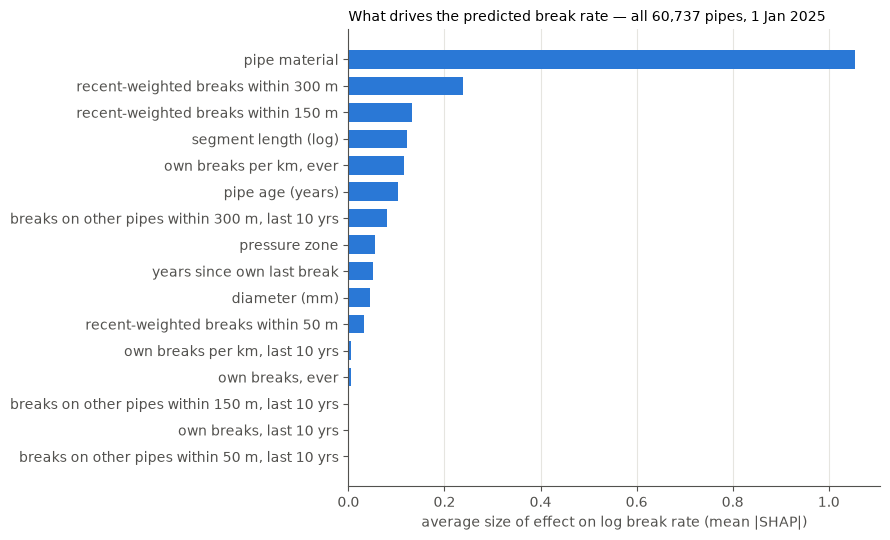

In [3]:
imp = sv.abs().mean().sort_values()
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh([NAMES[c] for c in imp.index], imp.values, color=BLUE, height=0.7)
ax.grid(axis="y", visible=False)
ax.set_xlabel("average size of effect on log break rate (mean |SHAP|)")
ax.set_title(f"What drives the predicted break rate — all {len(pipes):,} pipes, 1 Jan {YEAR}", fontsize=10, loc="left")
fig.tight_layout()
fig.savefig("../results/shap_importance.png", dpi=150)
(imp.sort_values(ascending=False).rename(index=NAMES).round(3).to_frame("mean |SHAP|"))

Related features share credit in SHAP (own history is split over four columns, nearby breaks over six), so
the same numbers grouped by what they describe:

In [4]:
GROUPS = {"pipe material": ["material"], "breaks on nearby pipes": [c for c in sv if c.startswith("nearby")],
          "own break history": ["breaks_all", "breaks_10y", "breaks_per_km", "breaks_per_km_10y", "years_since_break"],
          "segment length & diameter": ["log_length", "diameter"], "pipe age": ["age"], "pressure zone": ["p_zone"]}
grouped = pd.Series({g: sv[cols].sum(axis=1).abs().mean() for g, cols in GROUPS.items()}).sort_values(ascending=False)
grouped.round(3).to_frame("mean |SHAP| of the group")

,mean |SHAP| of the group
pipe material,1.054
breaks on nearby pipes,0.419
own break history,0.172
segment length & diameter,0.139
pipe age,0.104
pressure zone,0.056


**Findings:**

- **Pipe material is by far the strongest factor** (mean |SHAP| ≈ 1.05, i.e. a typical material effect
  multiplies the rate by ~2.9 up or down).
- **Breaks on nearby pipes come second as a group** (≈ 0.42) — ahead of the pipe's own break history
  (≈ 0.17). The model leans on the neighbourhood more than on the single segment.
- Segment length and diameter, age and pressure zone follow.

## 2. How does risk change with each key factor?

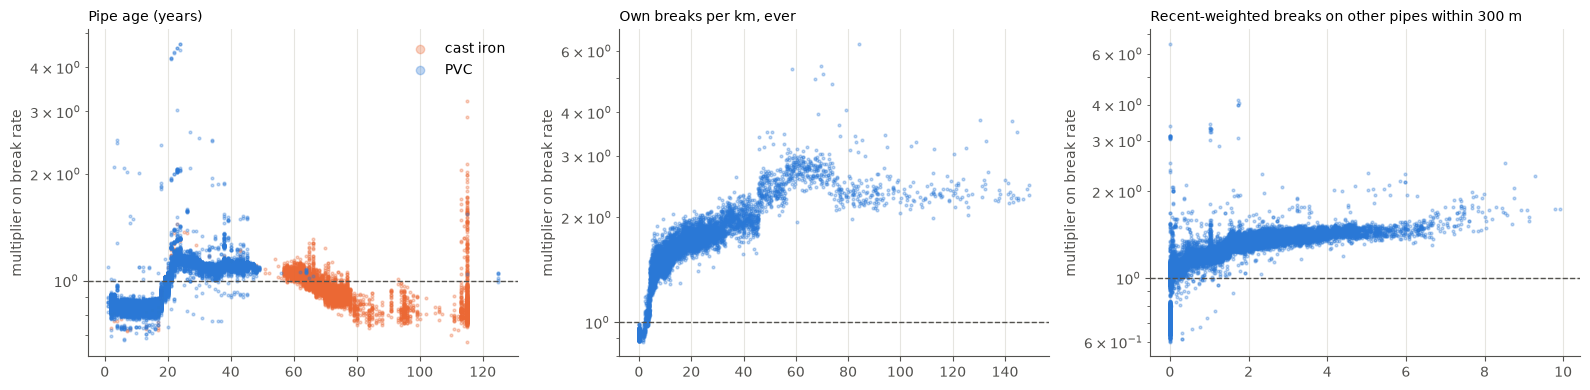

In [5]:
def effect(ax, col, title, xmax=None, by_material=False):
    x, m = pipes[col], np.exp(sv[col])
    keep = x <= xmax if xmax is not None else slice(None)
    if by_material:
        for mat, color in (("CI", ORANGE), ("PVC", BLUE)):
            sel = (pipes.material == mat) & (keep if xmax is not None else True)
            ax.scatter(x[sel], m[sel], s=4, alpha=0.3, color=color, label={"CI": "cast iron", "PVC": "PVC"}[mat])
        ax.legend(frameon=False, markerscale=3)
    else:
        ax.scatter(x[keep], m[keep], s=4, alpha=0.3, color=BLUE)
    ax.axhline(1, color=INK, linewidth=1, linestyle="--")
    ax.set_yscale("log"); ax.set_title(title, fontsize=10, loc="left"); ax.set_ylabel("multiplier on break rate")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
effect(axes[0], "age", "Pipe age (years)", by_material=True)
effect(axes[1], "breaks_per_km", "Own breaks per km, ever", xmax=150)
effect(axes[2], "nearby_300m_decay", "Recent-weighted breaks on other pipes within 300 m", xmax=10)
fig.tight_layout()
fig.savefig("../results/shap_effects.png", dpi=150)

**Findings** (each dot is one pipe; dashed line = no effect):

- **Own breaks per km:** no past break nudges risk down slightly (×~0.9); risk climbs steeply with the
  first breaks, to about ×2 at 20–40 breaks/km and ×2.5–3 at 50–70, then levels off.
- **Recent nearby breaks (300 m):** none → ×0.6–1.0; risk rises steadily with more recent breaks around the
  pipe, to about ×1.5–1.8 at the high end.
- **Age, within material:** young PVC (< 20 years) is pushed down (×~0.8). Among cast iron, the effect
  *falls* with age — 60-year-old cast iron is pushed up, 80–110-year-old cast iron pushed down. This matches
  the EDA (1950s pipes break more than 1910s–40s pipes): the oldest surviving cast iron is the sturdier
  remainder. Age alone is therefore not a good replacement rule.

## 3. Why is a particular pipe ranked where it is?

Three pipes from the 1 January 2025 ranking (segments of at least 20 m, so they're real stretches of main):

- **High risk** — near the top of the shortlist
- **Middle** — around where a 1%-of-network budget would cut off
- **Typical** — the median pipe

In [6]:
real = pipes[pipes.length >= 20].sort_values("rate", ascending=False)
real["rank_pct"] = (real.length.cumsum() / pipes.length.sum() * 100)
picks = {"High risk": real.index[0],
         "Middle (budget cut-off)": real.index[(real.rank_pct - 1.0).abs().argmin()],
         "Typical (median)": real.index[len(real) // 2]}

facts = pipes.loc[list(picks.values()), ["material", "install_year", "diameter", "length", "breaks_all",
                                         "breaks_10y", "nearby_150m_10y", "rate", "target"]]
facts.index = list(picks)
facts = facts.rename(columns={"breaks_all": "own breaks ever", "breaks_10y": "own breaks 10y",
                              "nearby_150m_10y": "nearby breaks 150m 10y", "rate": "predicted rate /km/yr",
                              "target": "actual breaks in 2025"})
facts.round(3)

,material,install_year,diameter,length,own breaks ever,own breaks 10y,nearby breaks 150m 10y,predicted rate /km/yr,actual breaks in 2025
High risk,CI,1910,150,26.177,1.0,1.0,7.0,2.229,0.0
Middle (budget cut-off),CI,1959,250,84.411,3.0,1.0,0.0,0.267,0.0
Typical (median),PVC,1986,150,159.255,0.0,0.0,1.0,0.005,0.0


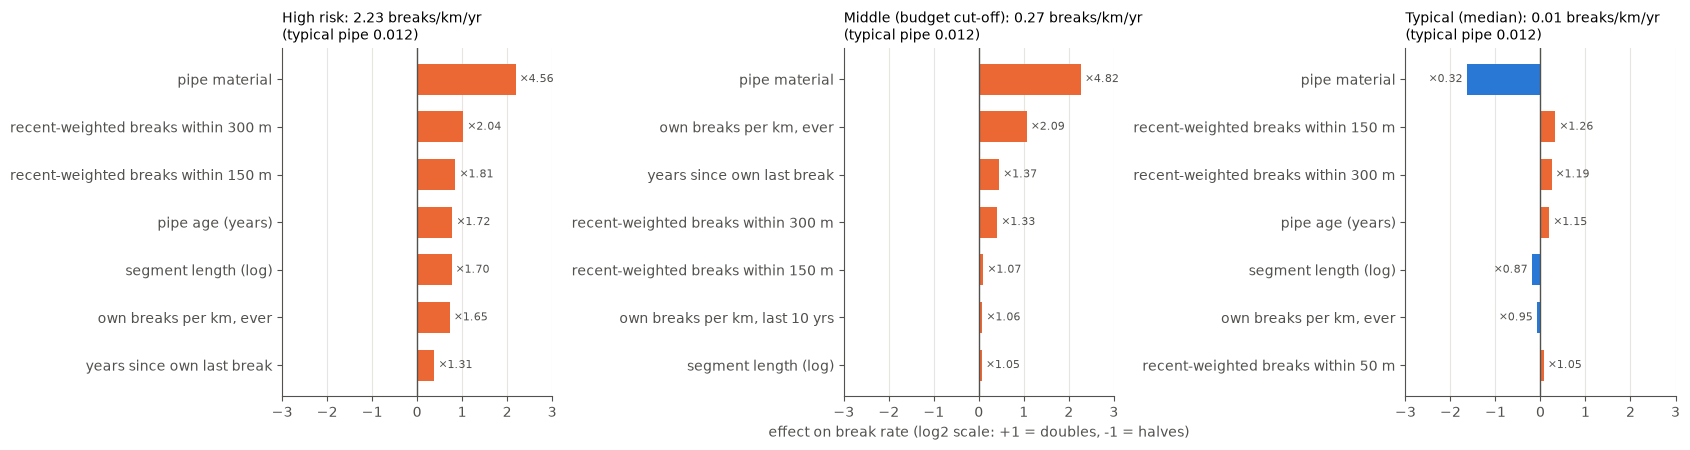

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), sharex=True)
for ax, (label, idx) in zip(axes, picks.items()):
    mult = np.exp(sv.loc[idx]).rename(index=NAMES)
    top = mult.reindex((np.log(mult)).abs().sort_values(ascending=False).index[:7])[::-1]
    ax.barh(top.index, np.log2(top.values), color=[ORANGE if v > 1 else BLUE for v in top.values], height=0.65)
    for y, v in enumerate(top.values):
        ax.text(np.log2(v), y, f" ×{v:.2f} ", va="center", ha="left" if v > 1 else "right", fontsize=8, color=INK)
    ax.axvline(0, color=INK, linewidth=1)
    ax.set_xlim(-3, 3)
    ax.grid(axis="y", visible=False)
    ax.set_title(f"{label}: {pipes.rate[idx]:.2f} breaks/km/yr\n(typical pipe {np.exp(base):.3f})", fontsize=10, loc="left")
axes[1].set_xlabel("effect on break rate (log2 scale: +1 = doubles, -1 = halves)")
fig.tight_layout()
fig.savefig("../results/shap_three_pipes.png", dpi=150)

In [8]:
def explain(idx, k=4):
    mult = np.exp(sv.loc[idx])
    top = (np.log(mult)).abs().sort_values(ascending=False).index[:k]
    parts = [f"{NAMES[c]} = {pipes.loc[idx, c] if c in ('material', 'p_zone') else round(float(pipes.loc[idx, c]), 1)} (×{mult[c]:.2f})" for c in top]
    return f"typical {np.exp(base):.3f} → predicted {pipes.rate[idx]:.3f} breaks/km/yr, mainly: " + "; ".join(parts)

for label, idx in picks.items():
    print(f"{label}:\n  {explain(idx)}\n")

High risk:
  typical 0.012 → predicted 2.229 breaks/km/yr, mainly: pipe material = CI (×4.56); recent-weighted breaks within 300 m = 5.4 (×2.04); recent-weighted breaks within 150 m = 3.6 (×1.81); pipe age (years) = 115.0 (×1.72)

Middle (budget cut-off):
  typical 0.012 → predicted 0.267 breaks/km/yr, mainly: pipe material = CI (×4.82); own breaks per km, ever = 35.5 (×2.09); years since own last break = 5.0 (×1.37); recent-weighted breaks within 300 m = 3.6 (×1.33)

Typical (median):
  typical 0.012 → predicted 0.005 breaks/km/yr, mainly: pipe material = PVC (×0.32); recent-weighted breaks within 150 m = 0.3 (×1.26); recent-weighted breaks within 300 m = 0.4 (×1.19); pipe age (years) = 39.0 (×1.15)



**Findings:**

- **High risk (cast iron, 1910, 26 m):** cast iron ×4.6, several recent breaks within 150–300 m (×2.0 and
  ×1.8), age ×1.7 → 2.23 breaks/km/yr, ~190× the typical pipe. It has only one break of its own — the
  **neighbourhood** puts it at the top.
- **Middle (cast iron, 1959, 84 m):** cast iron ×4.8 and its **own** record (3 breaks, ~35/km) ×2.1 →
  0.27 breaks/km/yr. This is the repeat-offender pattern the simple rule also catches.
- **Typical (PVC, 1986, 159 m):** PVC ×0.32 outweighs mild nearby effects → 0.005 breaks/km/yr.
- **"High risk" is still a small yearly chance:** the top pipe's 2.23 breaks/km/yr × 0.026 km ≈ 0.06
  expected breaks in 2025. None of the three broke in 2025 — the ranking concentrates breaks across many
  pipes rather than predicting which single pipe breaks.